<a href="https://colab.research.google.com/github/jingyig16/ufo-sightings/blob/main/ufo_sightings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CIS 5450 Final Project - UFO Shape Prediction**

# Part 1: Introduction

(todo)

# Part 2: Data Loading & Preprocessing

In [1]:
!pip install reverse_geocoder
!pip install plotly

In [2]:
import pandas as pd
import numpy as np
import re
import reverse_geocoder as rg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.neighbors import BallTree
import geopandas as gpd
from shapely.geometry import Point

import folium
from folium.plugins import HeatMap

import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
import warnings
warnings.filterwarnings("ignore", message="Downloading:", category=UserWarning)

## The UFO Sighting Dataset

###Information of The Raw Data

In [4]:
# Data loading via GitHub
github_url = 'https://raw.githubusercontent.com/jingyig16/ufo-sightings/refs/heads/main/ufo_sighting.csv'
ufo_df = pd.read_csv(github_url, low_memory=False)

In [5]:
ufo_df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,10/10/1949 20:30,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,4/27/2004,29.8830556,-97.941111
1,10/10/1949 21:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,12/16/2005,29.38421,-98.581082
2,10/10/1955 17:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,1/21/2008,53.2,-2.916667
3,10/10/1956 21:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,1/17/2004,28.9783333,-96.645833
4,10/10/1960 20:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,1/22/2004,21.4180556,-157.803611


In [6]:
ufo_df.columns = ufo_df.columns.str.strip().str.lower()
for i, col in enumerate(ufo_df.columns):
    print(f"{i+1}. {col}")

1. datetime
2. city
3. state
4. country
5. shape
6. duration (seconds)
7. duration (hours/min)
8. comments
9. date posted
10. latitude
11. longitude


In [7]:
len(ufo_df)

80332

In [8]:
ufo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80332 entries, 0 to 80331
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   datetime              80332 non-null  object 
 1   city                  80332 non-null  object 
 2   state                 74535 non-null  object 
 3   country               70662 non-null  object 
 4   shape                 78400 non-null  object 
 5   duration (seconds)    80332 non-null  object 
 6   duration (hours/min)  80332 non-null  object 
 7   comments              80317 non-null  object 
 8   date posted           80332 non-null  object 
 9   latitude              80332 non-null  object 
 10  longitude             80332 non-null  float64
dtypes: float64(1), object(10)
memory usage: 6.7+ MB


### Handling Redundant and Invalid Data

Since the UFO `shape` is our target variable for prediction, we removed all records where this field was missing. Supervised learning models require a known label for each training example in order to compute loss and evaluate performance. Instances without a recorded shape cannot contribute to the learning process and would otherwise introduce noise or bias into the model. Therefore, rows with null values in the shape column were excluded from the dataset.

In [9]:
ufo_df = ufo_df.dropna(subset=['shape'])

In [10]:
len(ufo_df)

78400

Moreover, since the UFO shape attribute is the target variable in our prediction task, it is important that each class contains enough examples for the model to learn meaningful patterns. However, the distribution of shapes is highly imbalanced, with several categories appearing only a handful of times. Extremely rare classes provide insufficient data for supervised learning and tend to introduce noise or instability during training. These classes can also lead to overfitting, as the model may memorize a few isolated examples rather than generalize from real patterns. To address this issue and improve model robustness, we consolidated all shapes with very low counts into “other” category. This grouping preserves the overall diversity of shapes while ensuring that each remaining class has enough support for reliable learning and evaluation.

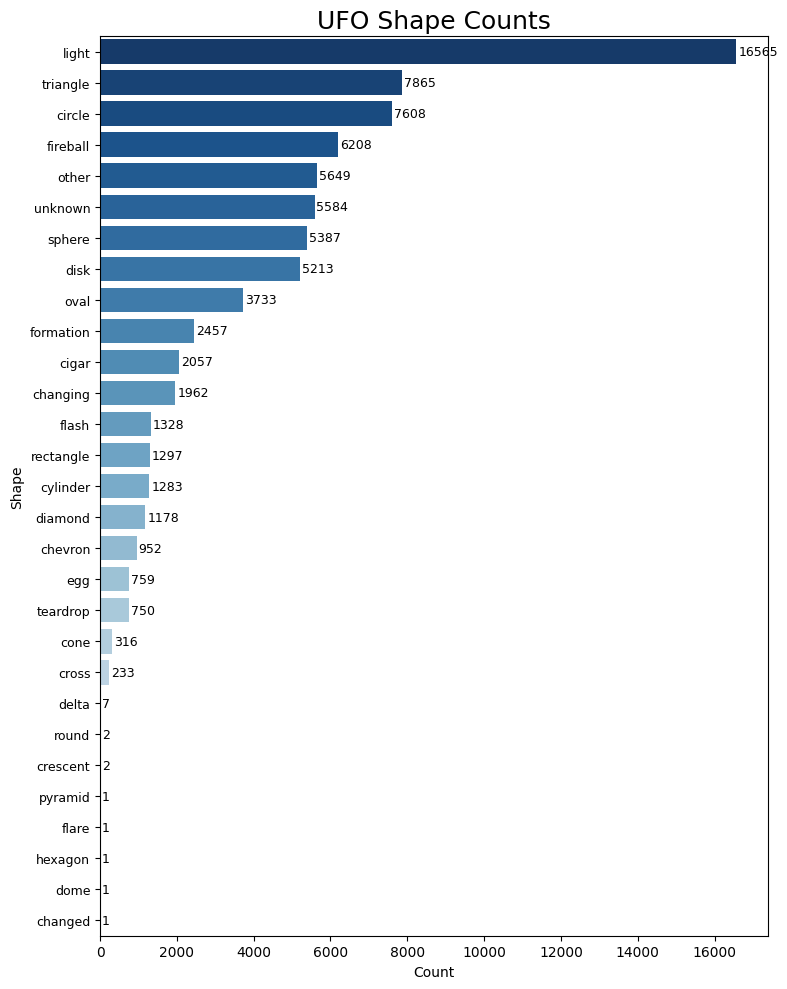

In [11]:
shape_counts = ufo_df['shape'].value_counts()

plt.figure(figsize=(8, 10))
ax = sns.barplot(
    x=shape_counts.values,
    y=shape_counts.index,
    hue=shape_counts.index,
    palette="Blues_r"
)
plt.title("UFO Shape Counts", fontsize=18)
plt.xlabel("Count")
plt.ylabel("Shape")
plt.yticks(fontsize=9)
for i, v in enumerate(shape_counts.values):
    ax.text(v + 50, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [12]:
shape_counts = ufo_df['shape'].value_counts()
rare_shapes = shape_counts[shape_counts < 200].index
ufo_df['shape'] = ufo_df['shape'].replace(rare_shapes, 'other')

In [13]:
ufo_cleaned = ufo_df.copy()

#### Drop Unused Columns

In [14]:
# Drop unused columns
ufo_cleaned = ufo_cleaned.drop(columns=["comments", "date posted","duration (hours/min)"])

The `duration (hours/min)` column was dropped because it duplicates the information in duration (seconds) but in inconsistent units. Keeping only the numeric duration simplifies analysis and ensures accurate quantitative modeling.

The `comments` column was removed since it contains unstructured text outside the scope of this study, which focuses on numerical and spatial patterns rather than linguistic content.

The `date posted` column was excluded because it reflects when a report was submitted, not when the sighting occurred. The true event timing is already captured in the `datetime` field, making date posted less meaningful for UFO pattern analysis.

### `datetime` Processing

#### Convert `datetime` to Datetime type

Converting the datetime column to datetime format ensures consistent and accurate time-based analysis and operations across the dataset.

We found that some records in `datetime` contained timestamps using "24:00", which is invalid in Python's datetime format. The value "24:00" represents midnight of the following day, but since most libraries only accept hours from 00 to 23, these entries caused conversion errors. To handle this, all "24:00" values were replaced with "00:00"

In [15]:
ufo_cleaned["datetime"] = (ufo_cleaned["datetime"].astype(str).apply(lambda x: re.sub(r"24:00", "00:00", x)))
ufo_cleaned["datetime"] = pd.to_datetime(ufo_cleaned["datetime"])

This small adjustment preserves the temporal meaning of the records while ensuring compatibility with pandas datetime operations.

#### Create a New Categorical Feature: `time_of_day`

In [16]:
ufo_cleaned["hour"] = ufo_cleaned["datetime"].dt.hour

In [17]:
def categorize_time_of_day(hour):
        if 6 <= hour < 9:
            return 'Dawn'
        elif 9 <= hour < 17:
            return 'Day'
        elif 17 <= hour < 21:
            return 'Dusk'
        else:
            return 'Night'

In [18]:
ufo_cleaned["time_of_day"] = ufo_cleaned["hour"].apply(categorize_time_of_day)

### Standardize `latitude` and `longitude`

In [19]:
def extract_numeric(value):
    """
    Extracts the first valid float-like number (with optional minus sign and decimal)
    from a string. Returns NaN if no valid number found.
    """
    if pd.isna(value):
        return None
    match = re.search(r"-?\d+\.?\d*", str(value))
    if match:
        return float(match.group())
    return None

In [20]:
ufo_cleaned["latitude"] = ufo_cleaned["latitude"].apply(extract_numeric)
ufo_cleaned["longitude"] = ufo_cleaned["longitude"].apply(extract_numeric)
# Convert to numeric just in case and drop invalid rows
ufo_cleaned["latitude"] = pd.to_numeric(ufo_cleaned["latitude"], errors="coerce")
ufo_cleaned["longitude"] = pd.to_numeric(ufo_cleaned["longitude"], errors="coerce")

In [21]:
ufo_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78400 entries, 0 to 80331
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            78400 non-null  datetime64[ns]
 1   city                78400 non-null  object        
 2   state               72742 non-null  object        
 3   country             69001 non-null  object        
 4   shape               78400 non-null  object        
 5   duration (seconds)  78400 non-null  object        
 6   latitude            78400 non-null  float64       
 7   longitude           78400 non-null  float64       
 8   hour                78400 non-null  int32         
 9   time_of_day         78400 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(1), object(6)
memory usage: 6.3+ MB


To ensure all coordinate information was standardized for downstream geospatial analysis, I implemented a custom cleaning pipeline using a regex-based function:*extract_numeric* to extract valid float-like numbers from potentially messy latitude and longitude entries. This approach handled irregular formats (e.g., values containing symbols, extra spaces, or text) and safely converted all coordinates to numeric types. After cleaning, both latitude and longitude columns contained 78,400 valid float64 values, confirming that all coordinate data were successfully retained and standardized.

### Standardize `city`, `state`, and `country`

In [22]:
# Extract coordinates
coords = list(zip(ufo_cleaned["latitude"], ufo_cleaned["longitude"]))
# Batch reverse-geocode
results = rg.search(coords)
# Create geocoded DataFrame and align
geo_df = pd.DataFrame(results)
geo_df.index = ufo_cleaned.index
# Replace state & country with standardized values
ufo_cleaned["city"] = geo_df["name"]
ufo_cleaned["state"] = geo_df["admin1"]
ufo_cleaned["country"] = geo_df["cc"]

Loading formatted geocoded file...


We regenerated the `city`, `state`, and `country` columns directly from the latitude and longitude coordinates to achieve a consistent and standardized geographic representation across all records. The original text-based fields contained irregularities such as inconsistent capitalization, abbreviations, and mixed naming conventions, which made them unreliable for quantitative analysis or model training. In contrast, latitude and longitude are precise and continuous numerical values that can be used to objectively infer standardized location information through reverse geocoding. This ensures that entries with identical coordinates map to the same administrative regions, eliminating human errors and variations in naming.


In [23]:
ufo_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 78400 entries, 0 to 80331
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   datetime            78400 non-null  datetime64[ns]
 1   city                78400 non-null  object        
 2   state               78400 non-null  object        
 3   country             78400 non-null  object        
 4   shape               78400 non-null  object        
 5   duration (seconds)  78400 non-null  object        
 6   latitude            78400 non-null  float64       
 7   longitude           78400 non-null  float64       
 8   hour                78400 non-null  int32         
 9   time_of_day         78400 non-null  object        
dtypes: datetime64[ns](1), float64(2), int32(1), object(6)
memory usage: 6.3+ MB


## City Features Dataset

(todo)explanation of this dataset

In [24]:
city_github_url = 'https://raw.githubusercontent.com/jingyig16/ufo-sightings/refs/heads/main/new_dataset/city_features.csv'
city_df = pd.read_csv(city_github_url, low_memory=False)

In [25]:
city_df.head()

,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id,wc_bio1,wc_bio4,wc_bio12,elevation_m,viirs_annual_ave
0,Tokyo,Tokyo,35.6870,139.7495,Japan,JP,JPN,Tōkyō,primary,37785000.0,1392685764,15.704166,769.836060,1431.0,33.0,28.124304
1,Jakarta,Jakarta,-6.1750,106.8275,Indonesia,ID,IDN,Jakarta,primary,33756000.0,1360771077,27.700001,37.598354,1958.0,6.0,32.622326
2,Delhi,Delhi,28.6100,77.2300,India,IN,IND,Delhi,admin,32226000.0,1356872604,25.170834,684.120056,730.0,214.0,67.107742
3,Guangzhou,Guangzhou,23.1300,113.2600,China,CN,CHN,Guangdong,admin,26940000.0,1156237133,22.320833,571.980041,1729.0,21.0,53.230152
4,Mumbai,Mumbai,19.0761,72.8775,India,IN,IND,Mahārāshtra,admin,24973000.0,1356226629,27.691668,182.356216,2159.0,6.0,37.921257


In [26]:
len(city_df)

48059

In [27]:
city_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48059 entries, 0 to 48058
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   city              48059 non-null  object 
 1   city_ascii        48057 non-null  object 
 2   lat               48059 non-null  float64
 3   lng               48059 non-null  float64
 4   country           48059 non-null  object 
 5   iso2              48026 non-null  object 
 6   iso3              48059 non-null  object 
 7   admin_name        47858 non-null  object 
 8   capital           15138 non-null  object 
 9   population        47808 non-null  float64
 10  id                48059 non-null  int64  
 11  wc_bio1           47484 non-null  float64
 12  wc_bio4           47484 non-null  float64
 13  wc_bio12          47484 non-null  float64
 14  elevation_m       47484 non-null  float64
 15  viirs_annual_ave  48055 non-null  float64
dtypes: float64(8), int64(1), object(7)
memor

In [28]:
city_df=city_df.rename(columns={
    "wc_bio1":"avg_annual_temp(°C)",
    "wc_bio4":"temp_seasonality",
    "wc_bio12":"annual_precipitation(mm)",
    "elevation_m":"elevation(m)"
})

(todo): explanation of features \
`temp_seasonality`:

`viirs_annual_ave`: annual average nighttime light intensity from satellite VIIRS data(unit: nW/cm²/sr)

In [29]:
city_cleaned = city_df.copy()

### Drop Unused Columns

In [30]:
city_cleaned = city_cleaned.drop(['city_ascii','iso2', 'iso3', 'admin_name', 'id', 'capital'], axis=1)

The `city_ascii` column was removed because the geographic position of each observation is already precisely defined by its latitude and longitude coordinates, and we will do standardization of city names.

The `iso2`and `iso3` columns were dropped because country information is already represented by the `country` field, while geographic location is fully captured by the `lat` and `lng` coordinates. Retaining multiple identifiers for the same attribute would introduce redundancy without adding analytical value.

The `admin_name`, `id` and `capital` columns were dropped because they contain administrative or metadata fields inherited from the original city dataset (e.g., province names, city IDs, or capital status) that are not relevant to the spatial analysis or the merging process with the UFO dataset. They were excluded to streamline the dataset and maintain focus on features directly related to location matching.

In [31]:
city_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48059 entries, 0 to 48058
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   city                      48059 non-null  object 
 1   lat                       48059 non-null  float64
 2   lng                       48059 non-null  float64
 3   country                   48059 non-null  object 
 4   population                47808 non-null  float64
 5   avg_annual_temp(°C)       47484 non-null  float64
 6   temp_seasonality          47484 non-null  float64
 7   annual_precipitation(mm)  47484 non-null  float64
 8   elevation(m)              47484 non-null  float64
 9   viirs_annual_ave          48055 non-null  float64
dtypes: float64(8), object(2)
memory usage: 3.7+ MB


### Standardize `latitude` and `longitude`



In [32]:
city_cleaned["lat"] = city_cleaned["lat"].apply(extract_numeric)
city_cleaned["lng"] = city_cleaned["lng"].apply(extract_numeric)

city_cleaned["lat"] = pd.to_numeric(city_cleaned["lat"])
city_cleaned["lng"] = pd.to_numeric(city_cleaned["lng"])

### Standardize `city`, `state`, and `country`

In [33]:
# Extract coordinates
coords = list(zip(city_cleaned["lat"], city_cleaned["lng"]))
# Batch reverse-geocode
results = rg.search(coords)
# Create geocoded DataFrame and align
geo_df = pd.DataFrame(results)
geo_df.index = city_cleaned.index
# Replace state & country with standardized values
city_cleaned["city"] = geo_df["name"]
city_cleaned["state"] = geo_df["admin1"]
city_cleaned["country"] = geo_df["cc"]

Use the same method as how we processed `city`, `state` and `country` names in `ufo_cleaned` to ensure consistency.

## Global Airports Dataset

(todo) intro to this dataset;

We include the Global Airports dataset to account for aviation activity that may influence UFO reports. Airports generate frequent aircraft traffic and night-time lighting, both of which are known sources of UFO misidentification. By incorporating accurate airport locations, we can measure each sighting's proximity to aviation infrastructure and control for these human-error factors in our analysis.

In [34]:
global_airports_github_url = 'https://raw.githubusercontent.com/jingyig16/ufo-sightings/refs/heads/main/new_dataset/world-airports.csv'
airports_df = pd.read_csv(global_airports_github_url, low_memory=False)

In [35]:
airports_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84109 entries, 0 to 84108
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 84109 non-null  int64  
 1   ident              84109 non-null  object 
 2   type               84109 non-null  object 
 3   name               84109 non-null  object 
 4   latitude_deg       84109 non-null  float64
 5   longitude_deg      84109 non-null  float64
 6   elevation_ft       69531 non-null  float64
 7   continent          44759 non-null  object 
 8   country_name       84109 non-null  object 
 9   iso_country        83841 non-null  object 
 10  region_name        84109 non-null  object 
 11  iso_region         84109 non-null  object 
 12  local_region       84092 non-null  object 
 13  municipality       79360 non-null  object 
 14  scheduled_service  84109 non-null  int64  
 15  gps_code           43697 non-null  object 
 16  icao_code          931

In [36]:
airports_df['type'].unique()

array(['large_airport', 'closed', 'medium_airport', 'small_airport',
       'seaplane_base', 'heliport', 'balloonport'], dtype=object)

In [37]:
irrelavant_types = ["balloonport", "seaplane_base","closed"]
airports_df=airports_df[~airports_df['type'].isin(irrelavant_types)]
airports_df=airports_df.drop(columns=['type'])

We removed the categories “balloonport, “seaplane_base,” and “closed” because they do not contribute meaningful aviation activity that could influence UFO sightings. Balloonports and seaplane bases operate primarily during daytime and produce minimal lighting or flight traffic. This means they are unlikely to cause people to confuse normal aircraft with UFOs, so they do not add useful information to our analysis.

In [38]:
airports_df=airports_df[['name','latitude_deg','longitude_deg']]

In [39]:
airports_df.head(5)

,name,latitude_deg,longitude_deg
0,London Heathrow Airport,51.470600,-0.461941
1,Los Angeles International Airport,33.942501,-118.407997
2,Chicago O'Hare International Airport,41.978600,-87.904800
3,John F Kennedy International Airport,40.639447,-73.779317
4,Hartsfield Jackson Atlanta International Airport,33.636700,-84.428101


## Country Education Level Dataset

(todo): intro to the dataset

In [40]:
edu_github_url = 'https://raw.githubusercontent.com/jingyig16/ufo-sightings/refs/heads/main/new_dataset/global_education_modified.csv'
edu_df = pd.read_csv(edu_github_url,low_memory=False)

To capture the cultural and socioeconomic context behind how UFO sightings are interpreted and reported, we include three national-level indicators: `Gross_Tertiary_Education_Enrollment`, `Youth_15_24_Literacy_Rate_Both`, and `Unemployment_Rate`. Prior work on UFO reporting and anomalous perception suggests that the way people describe unusual aerial phenomena, including the shape they report, is strongly influenced by cultural background, scientific literacy, and social conditions. Higher educational attainment and literacy reflect exposure to scientific reasoning and familiarity with aviation, astronomy, and satellite activity, which may shape how observers interpret ambiguous lights or objects. Meanwhile, unemployment rate serves as a proxy for broader socioeconomic conditions that may affect outdoor activity patterns, attention to the night sky, and even reporting behavior. By including this small set of culturally meaningful features, we aim to capture human-contextual factors that may influence how UFO shapes are perceived and documented.

In [41]:
edu_df.columns = edu_df.columns.str.strip()

In [42]:
edu_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 31 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Countries and areas                      202 non-null    object 
 1   Latitude                                 189 non-null    float64
 2   Longitude                                189 non-null    float64
 3   OOSR_Pre0Primary_Age_Male                202 non-null    int64  
 4   OOSR_Pre0Primary_Age_Female              202 non-null    int64  
 5   OOSR_Primary_Age_Male                    202 non-null    int64  
 6   OOSR_Primary_Age_Female                  202 non-null    int64  
 7   OOSR_Lower_Secondary_Age_Male            202 non-null    int64  
 8   OOSR_Lower_Secondary_Age_Female          202 non-null    int64  
 9   OOSR_Upper_Secondary_Age_Male            202 non-null    int64  
 10  OOSR_Upper_Secondary_Age_Female          202 non-n

In [58]:
edu_df = edu_df[['Latitude','Longitude','Gross_Tertiary_Education_Enrollment','Unemployment_Rate']].copy()
edu_df=edu_df.dropna()


## Join Dataframes

### City Features with UFO Sighting

In the city features dataset, `population`, `avg_annual_temp(°C)`, `temp_seasonality`, `annual_precipitation(mm)`, `elevation(m)`, and `viirs_annual_ave` contain missing values for some cities. If we simply merged each UFO sighting with the single nearest city, some UFO records would inherit missing feature values even though a slightly more distant nearby city has complete data.

To address this, we implemented a nearest–non-null matching procedure:

- For each UFO sighting, we identified the k nearest cities using BallTree K-nearest-neighbor search in projected coordinates.

- For each feature, we examined these candidate cities in order of distance (nearest → farther).

- We selected the closest city that actually has a valid (non-null) value for that feature.

- We also recorded the distance to the city that supplied the data, producing a meaningful measure of spatial accuracy.

This approach preserves geographic proximity while ensuring that we do not propagate missing values. It produces feature assignments that are both spatially reasonable (always taking the closest available city) and data-complete (never selecting a city with missing information if a slightly farther city has valid data). The resulting dataset is therefore more robust for downstream modeling and analysis.

In [44]:
def ufo_with_city_features(g_ufo_m, g_cities_m, features_to_match, k=5):
    """
    Find the closest city (within k candidates) that has non-null values for each feature
    and compute the distance to the specific fallback city used for that feature.
    """
    # Extract (x, y) coordinates for KNN search
    city_coords = np.vstack([g_cities_m.geometry.x, g_cities_m.geometry.y]).T
    ufo_coords  = np.vstack([g_ufo_m.geometry.x, g_ufo_m.geometry.y]).T
    # Build a BallTree from city coordinates
    tree = BallTree(city_coords)
    # Query k nearest cities for each UFO point
    # dists[i, j] = distance from UFO i to its j-th nearest city
    # idxs[i, j]  = row index in g_cities_m of that j-th nearest city
    dists, idxs = tree.query(ufo_coords, k=k)

    result = g_ufo_m.copy()

    feature_dist_cols = []  #To store temporary distance columns here (one per feature).
    # Find fallback for each feature
    for col in features_to_match:
        chosen_vals = []
        chosen_dists = []

        for u in range(len(idxs)):
            candidates = idxs[u]       # k nearest city indices
            distances = dists[u]       # the distances from u-th UFO to each of the k cities.
            found = False
            for rank, city_idx in enumerate(candidates):
                val = g_cities_m.iloc[city_idx][col]
                if pd.notnull(val):
                    chosen_vals.append(val)               # record fallback feature values
                    chosen_dists.append(distances[rank])  # record fallback distance
                    found = True
                    break
            if not found:
                chosen_vals.append(np.nan)
                chosen_dists.append(np.nan)
        # Write chosen values to result
        result[col] = chosen_vals
        # Store distance column temporarily
        dist_col_name = f"__dist_{col}"
        result[dist_col_name] = chosen_dists
        feature_dist_cols.append(dist_col_name)

    # final dist_m: max distance across all fallback distances for this UFO record
    result["dist_m"] = result[feature_dist_cols].max(axis=1)
    # Remove temporary per-feature dist columns
    result = result.drop(columns=feature_dist_cols)

    return result

In [45]:
# A GeoDataFrame is like a normal DataFrame but supports spatial operations.
# geometry=gpd.points_from_xy(...): Converts each (longitude, latitude) pair into a Point geometry object since GeoPandas requires a geometry column to do spatial joins.
# crs="EPSG:4326": Sets the coordinate reference system (CRS) to the standard GPS coordinates(EPSG:4326)
g_ufo   = gpd.GeoDataFrame(ufo_cleaned, geometry=gpd.points_from_xy(ufo_cleaned.longitude, ufo_cleaned.latitude), crs="EPSG:4326")
g_cities= gpd.GeoDataFrame(city_cleaned, geometry=gpd.points_from_xy(city_cleaned.lng, city_cleaned.lat), crs="EPSG:4326")
# EPSG 3857 is a metric projection, meaning its units are meters.
g_ufo_m    = g_ufo.to_crs(3857)
g_cities_m = g_cities.to_crs(3857)

In [46]:
features_to_match= [
    "population",
    "avg_annual_temp(°C)",
    "temp_seasonality",
    "annual_precipitation(mm)",
    "elevation(m)",
    "viirs_annual_ave"
]
joined = ufo_with_city_features(g_ufo_m, g_cities_m, features_to_match, k=5)

#### Processing the joined dataframe

We want to attach city-level climate and environmental information (like temperature, precipitation, elevation, and nighttime light) to each UFO sighting.
Since these climate variables are measured at the city level, which represents a fairly large surrounding area, we assume that a city's climate represents the conditions within 100 km around that (latitude,longitude).
Based on this assumption, we link each UFO sighting to the nearest city, but only if it is within 100 km.
This way, the environmental information we attach to each sighting is accurate and geographically relevant.

In [47]:
# Filter out far matches > 100 km)
joined = joined[joined['dist_m'] <= 100000]
joined = joined.drop(columns=['dist_m'])

We drop the `geometry` column because it is only required by GeoPandas for spatial operations, and once the spatial matching is complete, the geometry objects are no longer needed.

In [48]:
joined = joined.drop(columns=['geometry'])

In [49]:
joined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76559 entries, 0 to 80331
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   datetime                  76559 non-null  datetime64[ns]
 1   city                      76559 non-null  object        
 2   state                     76559 non-null  object        
 3   country                   76559 non-null  object        
 4   shape                     76559 non-null  object        
 5   duration (seconds)        76559 non-null  object        
 6   latitude                  76559 non-null  float64       
 7   longitude                 76559 non-null  float64       
 8   hour                      76559 non-null  int32         
 9   time_of_day               76559 non-null  object        
 10  population                76559 non-null  float64       
 11  avg_annual_temp(°C)       76559 non-null  float64       
 12  temp_seasonality       

### Airports with UFO Sighting

To quantify how close each UFO sighting occurred to major airports, we calculated the distance from every sighting to its nearest airport using airport latitude/longitude data. We built a BallTree with the haversine metric to correctly compute great-circle distances on Earth and identified the closest airport for each UFO point. The resulting feature, `dist_to_nearest_airport(m)`, indicates how near the sighting was to an airport, helping us evaluate whether airport lighting or aircraft operations might contribute to some reports.


In [50]:
airport_coords = np.vstack([airports_df["longitude_deg"].values,airports_df["latitude_deg"].values]).T
ufo_coords = np.vstack([joined["longitude"].values,joined["latitude"].values]).T
# Convert degrees → radians for haversine
airport_rad = np.radians(airport_coords)
ufo_rad = np.radians(ufo_coords)
# Build BallTree for nearest-neighbor search
tree = BallTree(airport_rad, metric='haversine')
# Query nearest airport record for each UFO sighting
dists_rad, idxs = tree.query(ufo_rad, k=1)
earth_radius_m = 6371000  # meters
# Calculate the distance
dists_m = dists_rad[:, 0] * earth_radius_m
joined["dist_to_nearest_airport(m)"] = dists_m

### Country Education Level with UFO Sighting

In [51]:
# edu_df["Latitude"] = edu_df["Latitude"].apply(extract_numeric)
# edu_df["Longitude"] = edu_df["Longitude"].apply(extract_numeric)

# edu_df["Latitude"] = pd.to_numeric(edu_df["Latitude"])
# edu_df["Longitude"] = pd.to_numeric(edu_df["Longitude"])

# edu_df=edu_df.dropna(subset=['Latitude','Longitude'])

In [52]:
# # Extract coordinates
# coords = list(zip(edu_df["Latitude"], edu_df["Longitude"]))
# # Batch reverse-geocode
# results = rg.search(coords)
# # Create geocoded DataFrame and align
# geo_df = pd.DataFrame(results)
# geo_df.index = edu_df.index
# # Replace state & country with standardized values
# edu_df["country"] = geo_df["cc"]

In [53]:
# joined.merge(edu_df,on="country",how="inner").info()

In [60]:
edu_coords = np.vstack([edu_df["Longitude"].values, edu_df["Latitude"].values]).T
ufo_coords = np.vstack([joined["longitude"].values, joined["latitude"].values]).T
# Convert degrees → radians for haversine
edu_rad = np.radians(edu_coords)
ufo_rad = np.radians(ufo_coords)
# Build BallTree for nearest-neighbor search
tree = BallTree(edu_rad, metric='haversine')
# Query nearest education record for each UFO sighting
dists, idxs = tree.query(ufo_rad, k=1)
# Add the matched columns
joined["Gross_Tertiary_Education_Enrollment"] = edu_df["Gross_Tertiary_Education_Enrollment"].iloc[idxs[:,0]].values
joined["Unemployment_Rate"] = edu_df["Unemployment_Rate"].iloc[idxs[:,0]].values

# Part 3: Exploratory Data Analysis


## 3.1 Country-Level Shape Distributions

To examine whether country-level features carry predictive value for UFO shape classification, we begin by analyzing how reported shapes vary **across countries**.

### 3.1.1 UFO Sighting Frequency across Countries

As a first step, we examine the geographic distribution of UFO sighting frequency. Understanding where reports are concentrated is essential, because cross-country differences in reporting activity may reflect underlying social or environmental conditions that also affect the types of shapes people describe. Establishing this baseline helps contextualize later analyses of shape distributions and ensures that any observed shape patterns are interpreted in light of the underlying reporting landscape.


In [62]:
# Assign a weight of 1 to every sighting
plot_df = joined.copy()
plot_df["intensity"] = 1
heat_data = plot_df[["latitude", "longitude", "intensity"]].values.tolist()

# Custom bright heatmap color gradient
custom_gradient = {0.0: "#0000FF",0.4: "#00FFFF",0.6: "#00FF00",0.8: "#FFFF00",1.0: "#FF0000",   }

# Create a bounded world map
m = folium.Map(location=[20, 0],zoom_start=2,min_zoom=2,max_bounds=True,tiles="CartoDB dark_matter",
               width="85%",height="85%",control_scale=False)
# Add the heatmap layer
HeatMap(heat_data,radius=18,blur=12,min_opacity=0.3,max_zoom=4,gradient=custom_gradient).add_to(m)

# Display the map
m

The global heatmap of UFO sighting frequency shows clear geographic differences. North America and parts of Europe report many more sightings, while large areas of Africa and South America report very few. These differences likely reflect country-level factors that affect how often people submit reports, such as education level, literacy, internet access, and the strength of online reporting systems. Countries with better access to information and communication tools may contribute more sightings to databases like NUFORC, regardless of the true underlying rate of unusual events.

This pattern is important for modeling because it shows that country-level features influence not only where sightings occur but also how likely they are to be reported. These social and geographic factors may also affect how people interpret and describe what they see. As a result, such features may provide useful predictive signal for UFO shape classification and help us better understand differences in reporting behavior across countries.

### 3.1.2 UFO Shape Distributions within each Country

The global distribution of sighting counts indicates that reporting frequency is strongly shaped by country-specific factors. If these factors influence whether a sighting is reported, they may also influence how it is reported. To test this idea, we turn to the normalized distribution of UFO shapes across countries.

In [63]:
# Count sightings per shape per country
df_counts = (joined.groupby(['country', 'shape']).size().reset_index(name='count'))

# Normalize within each country
totals = df_counts.groupby('country')['count'].sum().reset_index(name='total')
df_norm = df_counts.merge(totals, on='country')
df_norm['pct'] = df_norm['count'] / df_norm['total']

# Pivot to matrix
heatmap_df = df_norm.pivot(index='country',columns='shape',values='pct').fillna(0)

# Plot
fig = px.imshow(heatmap_df, color_continuous_scale="Viridis",aspect="auto",height=1000,width=800,
                title="UFO Shape Distribution Across 158 Countries (Normalized)")

fig.update_layout(xaxis_title="UFO Shape",yaxis_title="Country",)
fig.show()


This heatmap shows the normalized distribution of UFO shapes across 158 countries.
- Each row = country
- Each column = UFO shape
- Each cell = percentage of that shape within that country's sightings

Because each row is normalized, bright (yellow) cells indicate a shape that is unusually dominant within that country.

The heatmap shows clear cross-country variance in the distribution of UFO shapes.
Since different countries exhibit different dominant shapes,
this indicates that country-level features carry useful information about the expected UFO shape.


### 3.1.3 Most Frequently Reported Countries

TODO

## 3.2 City-Level Feature Relationships within North America

In [ ]:
# Filter North America: US, Canada, Mexico
na_countries = ["US", "CA", "MX"]
na_df = joined[joined["country"].isin(na_countries)].copy()

na_df.shape

(71213, 18)

### 3.2.1 Most Frequently Reported Cities

In [64]:
city_counts = na_df.groupby("city").size().reset_index(name="sightings").sort_values("sightings", ascending=False)

# Plot top 20 cities
plt.figure(figsize=(10, 6))
sns.barplot(data=city_counts.head(20),
    x="sightings", y="city")
plt.title("Top 20 North American Cities by UFO Sightings")
plt.xlabel("Number of Sightings")
plt.ylabel("City")
plt.show()

NameError: name 'na_df' is not defined

### 3.2.2 Population vs. Sightings

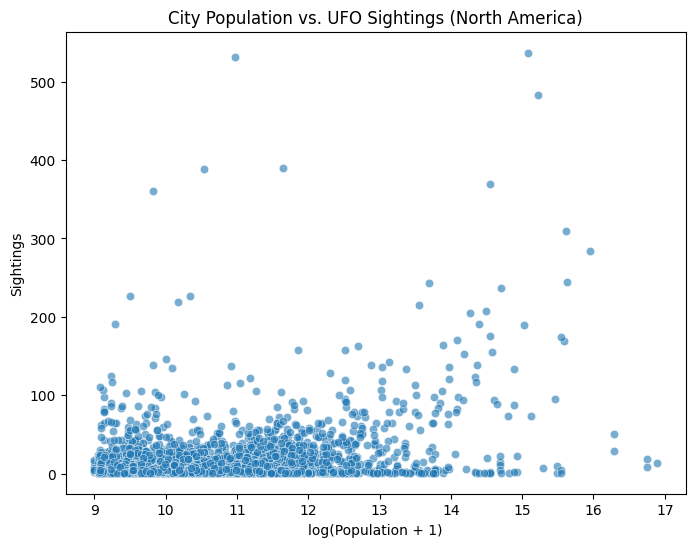

In [ ]:
pop_df = (na_df.groupby("city")
        .agg({"population": "first", "shape": "count"})
        .rename(columns={"shape": "sightings"})
        .reset_index())

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pop_df,
    x=np.log1p(pop_df["population"]),
    y=pop_df["sightings"],
    alpha=0.6
)
plt.title("City Population vs. UFO Sightings (North America)")
plt.xlabel("log(Population + 1)")
plt.ylabel("Sightings")
plt.show()


### 3.2.3 Nighttime Lights (Urbanization) vs. Sightings

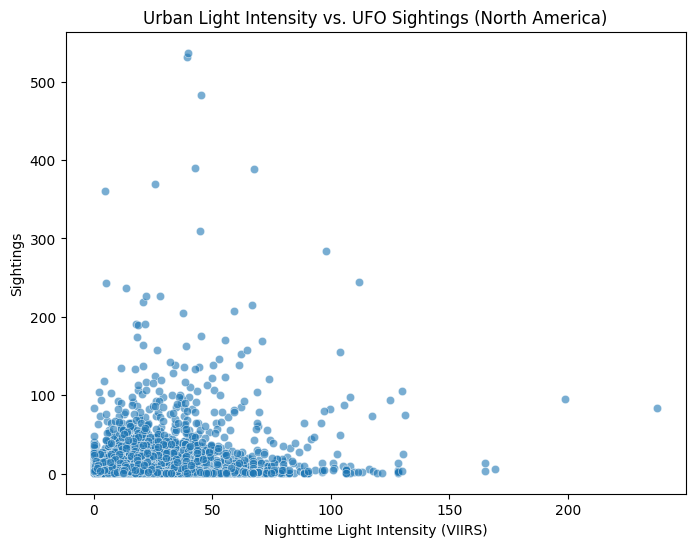

In [ ]:
light_df = (na_df.groupby("city")
         .agg({
             "viirs_annual_ave": "mean",
             "shape": "count"})
         .rename(columns={"shape": "sightings"})
         .reset_index())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=light_df,
    x="viirs_annual_ave",
    y="sightings",
    alpha=0.6
)
plt.title("Urban Light Intensity vs. UFO Sightings (North America)")
plt.xlabel("Nighttime Light Intensity (VIIRS)")
plt.ylabel("Sightings")
plt.show()


## 3.3 Distance to Airport EDA

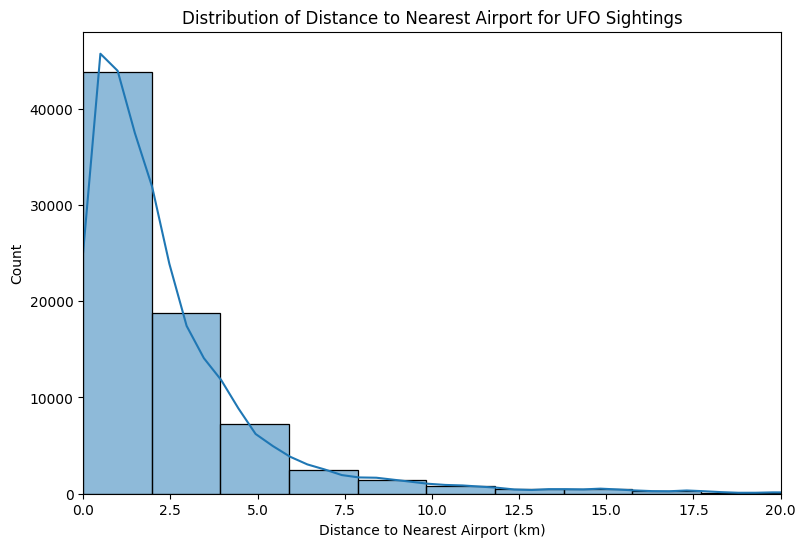

In [ ]:
plt.figure(figsize=(9,6))
sns.histplot(joined["dist_to_nearest_airport(m)"]/1000, bins=50, kde=True)
plt.xlim(0, 20)
plt.xlabel("Distance to Nearest Airport (km)")
plt.ylabel("Count")
plt.title("Distribution of Distance to Nearest Airport for UFO Sightings")
plt.show()


2.5km之内最多 - 很有可能误判，飞机会影响人判断是不是ufo

## 3.4 Time-based pattern

In [ ]:
def prepare_temporal_features(df):
    """Extract temporal features from datetime column"""
    df = df.copy()
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['day_of_week'] = df['datetime'].dt.dayofweek
    df['decade'] = (df['year'] // 10) * 10
    df['season'] = df['month'].apply(lambda x: 'Winter' if x in [12, 1, 2]
                                               else 'Spring' if x in [3, 4, 5]
                                               else 'Summer' if x in [6, 7, 8]
                                               else 'Fall')

    # Time of day categories
    def categorize_time_of_day(hour):
        if 5 <= hour < 9:
            return 'Dawn'
        elif 9 <= hour < 17:
            return 'Day'
        elif 17 <= hour < 21:
            return 'Dusk'
        else:
            return 'Night'

    df['time_of_day'] = df['hour'].apply(categorize_time_of_day)

    return df

### 3.4.1 Decades UFO Shapes Distributions

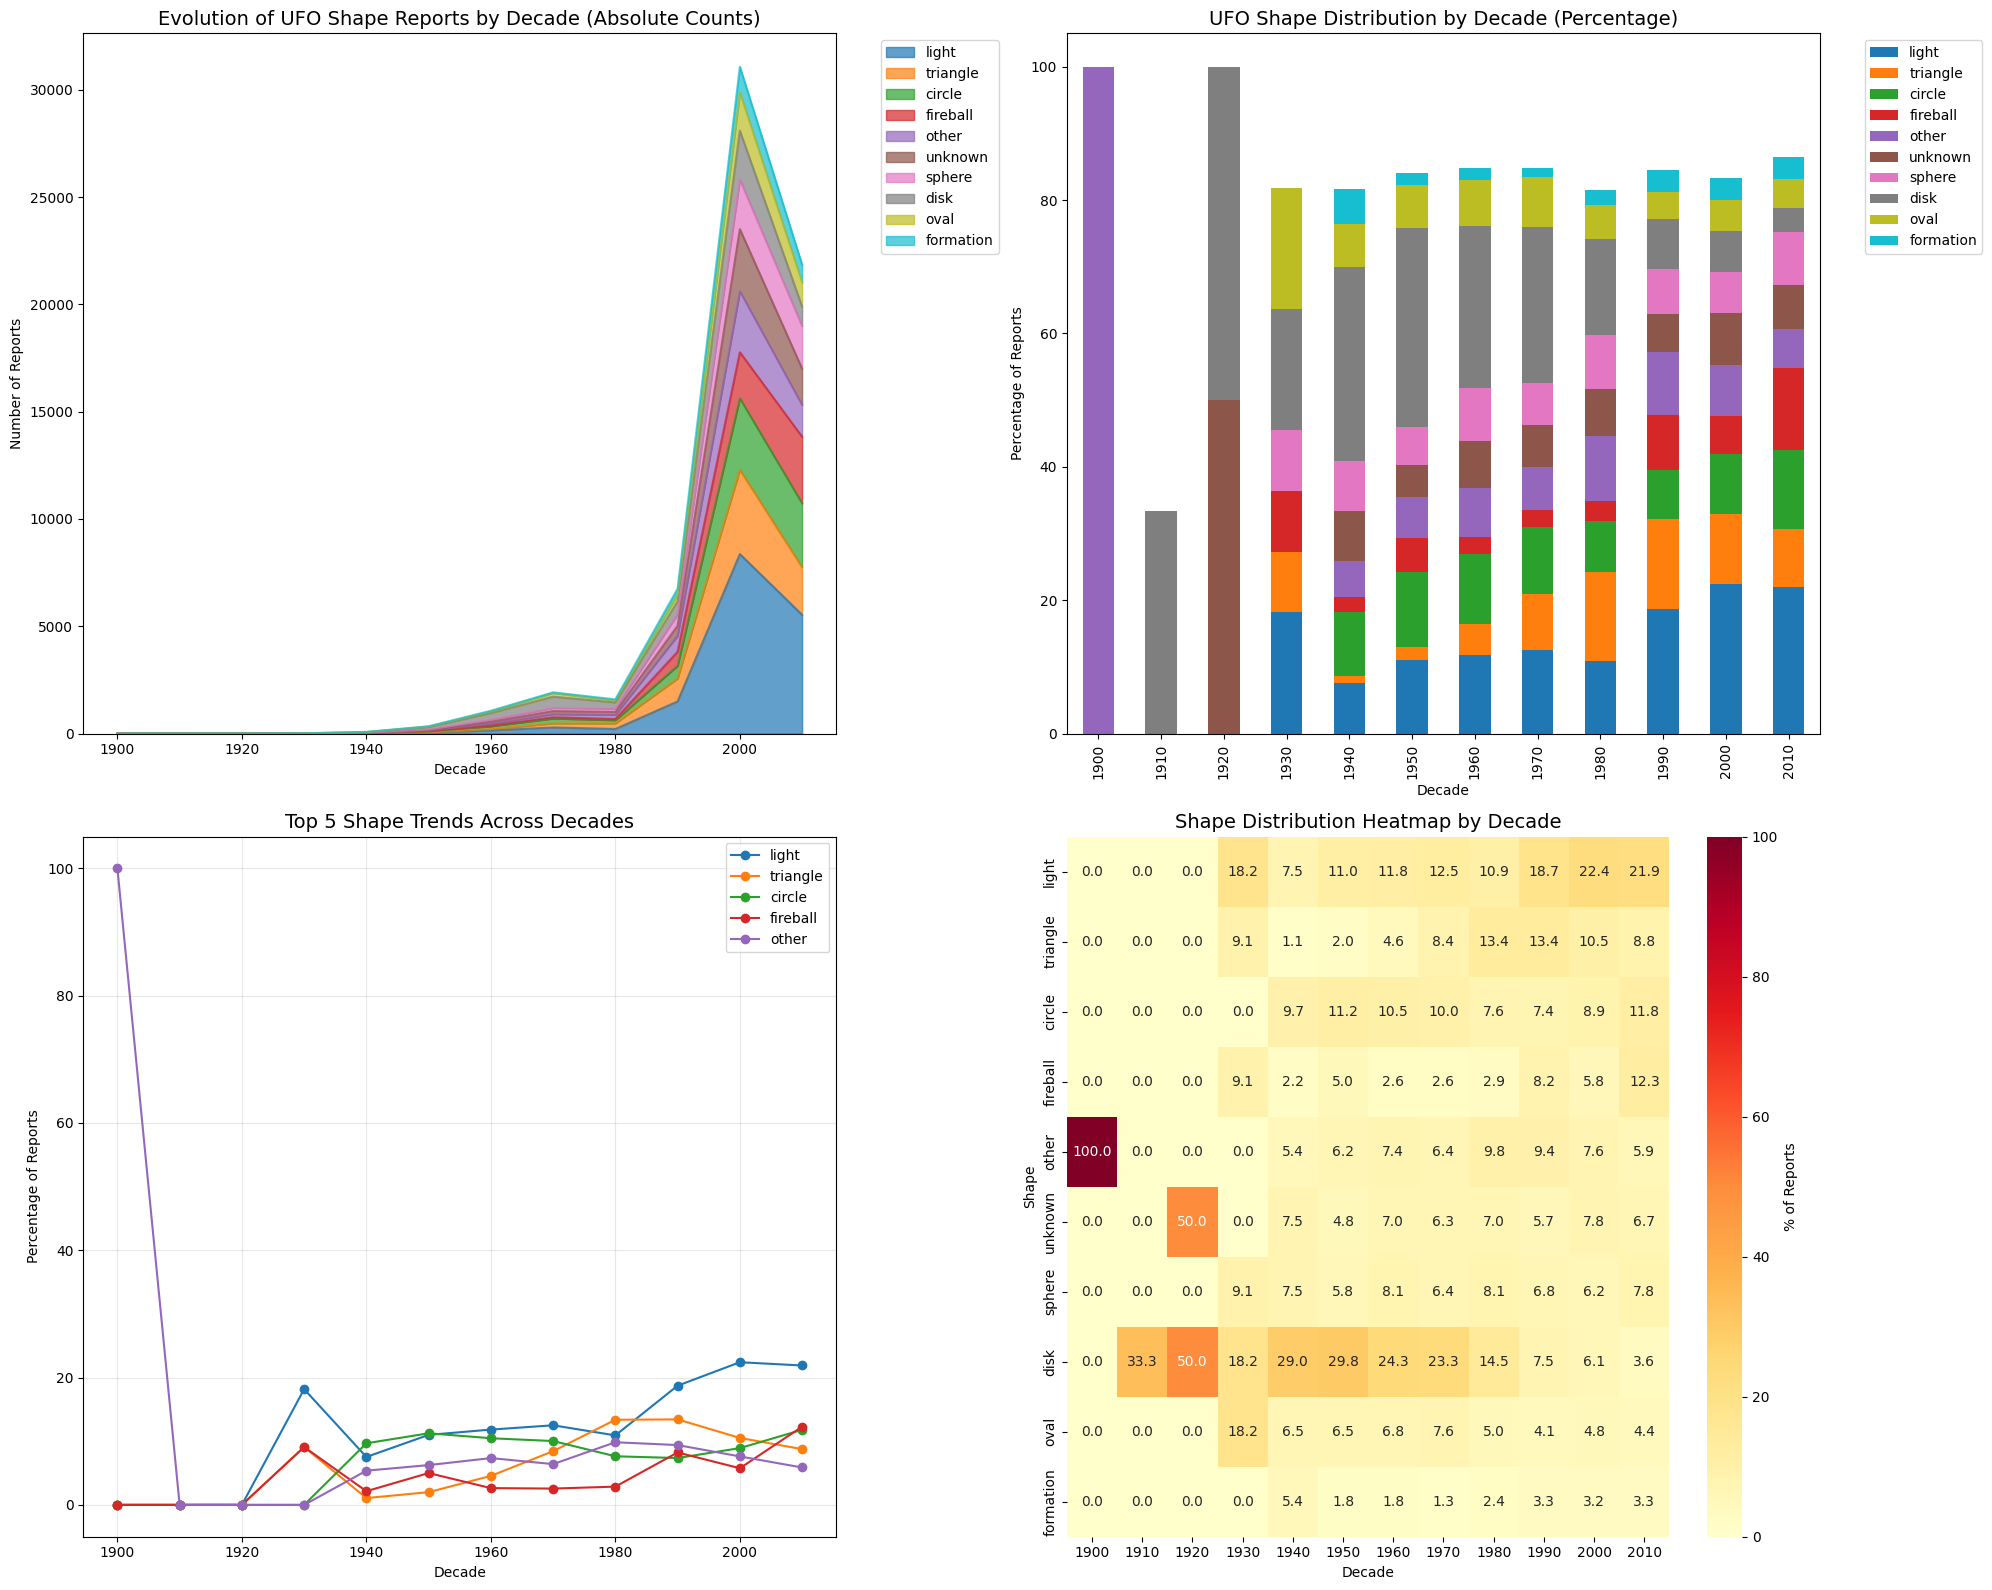


Key Insights from Decade Analysis:
----------------------------------------
1900s: Most common shape was 'other' (100.0%)
1910s: Most common shape was 'cigar' (66.7%)
1920s: Most common shape was 'disk' (50.0%)
1930s: Most common shape was 'disk' (18.2%)
1940s: Most common shape was 'disk' (29.0%)
1950s: Most common shape was 'disk' (29.8%)
1960s: Most common shape was 'disk' (24.3%)
1970s: Most common shape was 'disk' (23.3%)
1980s: Most common shape was 'disk' (14.5%)
1990s: Most common shape was 'light' (18.7%)
2000s: Most common shape was 'light' (22.4%)
2010s: Most common shape was 'light' (21.9%)


In [ ]:
# Apply temporal feature extraction
joined_temporal = prepare_temporal_features(joined)

# Get top shapes for focused analysis
top_n_shapes = 10
top_shapes = joined_temporal['shape'].value_counts().head(top_n_shapes).index.tolist()

# Create decade distribution
decade_shape = joined_temporal.groupby(['decade', 'shape']).size().unstack(fill_value=0)
decade_shape_pct = decade_shape.div(decade_shape.sum(axis=1), axis=0) * 100

# Visualize decade trends
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# Plot 1: Stacked area chart for top shapes over decades
decade_top = decade_shape[top_shapes]
decade_top.plot(kind='area', stacked=True, ax=axes[0,0], alpha=0.7)
axes[0,0].set_title('Evolution of UFO Shape Reports by Decade (Absolute Counts)', fontsize=14)
axes[0,0].set_xlabel('Decade')
axes[0,0].set_ylabel('Number of Reports')
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Percentage distribution over decades
decade_shape_pct[top_shapes].plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title('UFO Shape Distribution by Decade (Percentage)', fontsize=14)
axes[0,1].set_xlabel('Decade')
axes[0,1].set_ylabel('Percentage of Reports')
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 3: Line plot showing trends for each shape
for shape in top_shapes[:5]:  # Top 5 for clarity
    axes[1,0].plot(decade_shape_pct.index, decade_shape_pct[shape], marker='o', label=shape)
axes[1,0].set_title('Top 5 Shape Trends Across Decades', fontsize=14)
axes[1,0].set_xlabel('Decade')
axes[1,0].set_ylabel('Percentage of Reports')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Heatmap of decade-shape distribution
sns.heatmap(decade_shape_pct[top_shapes].T, annot=True, fmt='.1f',
            cmap='YlOrRd', ax=axes[1,1], cbar_kws={'label': '% of Reports'})
axes[1,1].set_title('Shape Distribution Heatmap by Decade', fontsize=14)
axes[1,1].set_xlabel('Decade')
axes[1,1].set_ylabel('Shape')

plt.tight_layout()
plt.show()

# Statistical summary
print("\nKey Insights from Decade Analysis:")
print("-" * 40)
for decade in sorted(decade_shape_pct.index):
    top_shape = decade_shape_pct.loc[decade].idxmax()
    print(f"{decade}s: Most common shape was '{top_shape}' ({decade_shape_pct.loc[decade, top_shape]:.1f}%)")


3.4.4 图 - 时间越近report越多

2，3 - shape上时间的推移的变化

### 3.4.2 Seasonal and Monthly UFO Shape Distributions

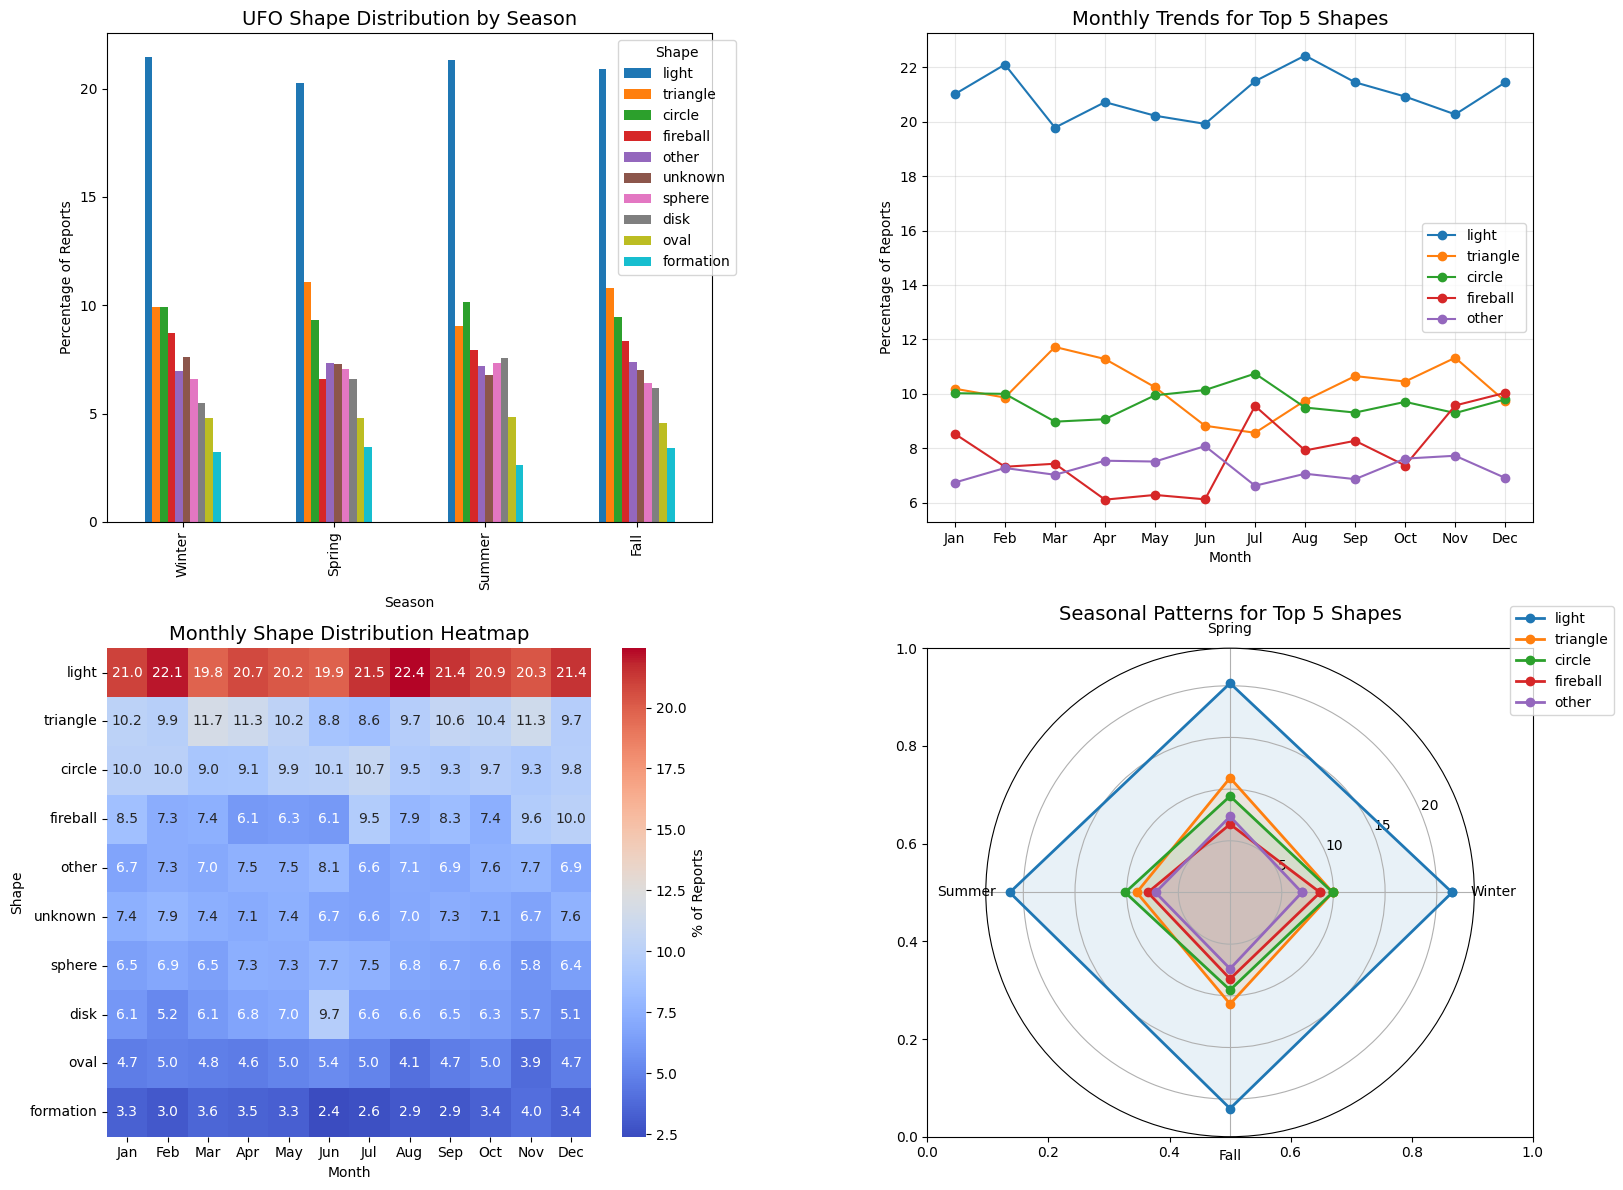

In [ ]:
# Create seasonal and monthly distributions
season_shape = joined_temporal.groupby(['season', 'shape']).size().unstack(fill_value=0)
month_shape = joined_temporal.groupby(['month', 'shape']).size().unstack(fill_value=0)

# Normalize for percentages
season_shape_pct = season_shape.div(season_shape.sum(axis=1), axis=0) * 100
month_shape_pct = month_shape.div(month_shape.sum(axis=1), axis=0) * 100

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Seasonal distribution
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
season_shape_pct.reindex(season_order)[top_shapes].plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('UFO Shape Distribution by Season', fontsize=14)
axes[0,0].set_xlabel('Season')
axes[0,0].set_ylabel('Percentage of Reports')
axes[0,0].legend(title='Shape', bbox_to_anchor=(1.05, 1))

# Plot 2: Monthly trends for top shapes
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for shape in top_shapes[:5]:
    axes[0,1].plot(range(1, 13), month_shape_pct[shape], marker='o', label=shape)
axes[0,1].set_title('Monthly Trends for Top 5 Shapes', fontsize=14)
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Percentage of Reports')
axes[0,1].set_xticks(range(1, 13))
axes[0,1].set_xticklabels(month_names)
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Heatmap of monthly shape distribution
sns.heatmap(month_shape_pct[top_shapes].T, annot=True, fmt='.1f',
            cmap='coolwarm', ax=axes[1,0], cbar_kws={'label': '% of Reports'})
axes[1,0].set_title('Monthly Shape Distribution Heatmap', fontsize=14)
axes[1,0].set_xlabel('Month')
axes[1,0].set_xticklabels(month_names)
axes[1,0].set_ylabel('Shape')

# Plot 4: Radar chart for seasonal patterns (top 5 shapes)
from math import pi
categories = season_order
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(2, 2, 4, projection='polar')
for shape in top_shapes[:5]:
    values = season_shape_pct.reindex(season_order)[shape].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=shape)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, max(season_shape_pct[top_shapes].max()) * 1.1)
ax.set_title('Seasonal Patterns for Top 5 Shapes', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

留第一个图 - 表明好像没什么关系

### 3.4.3 Time-of-Day Patterns for Shapes

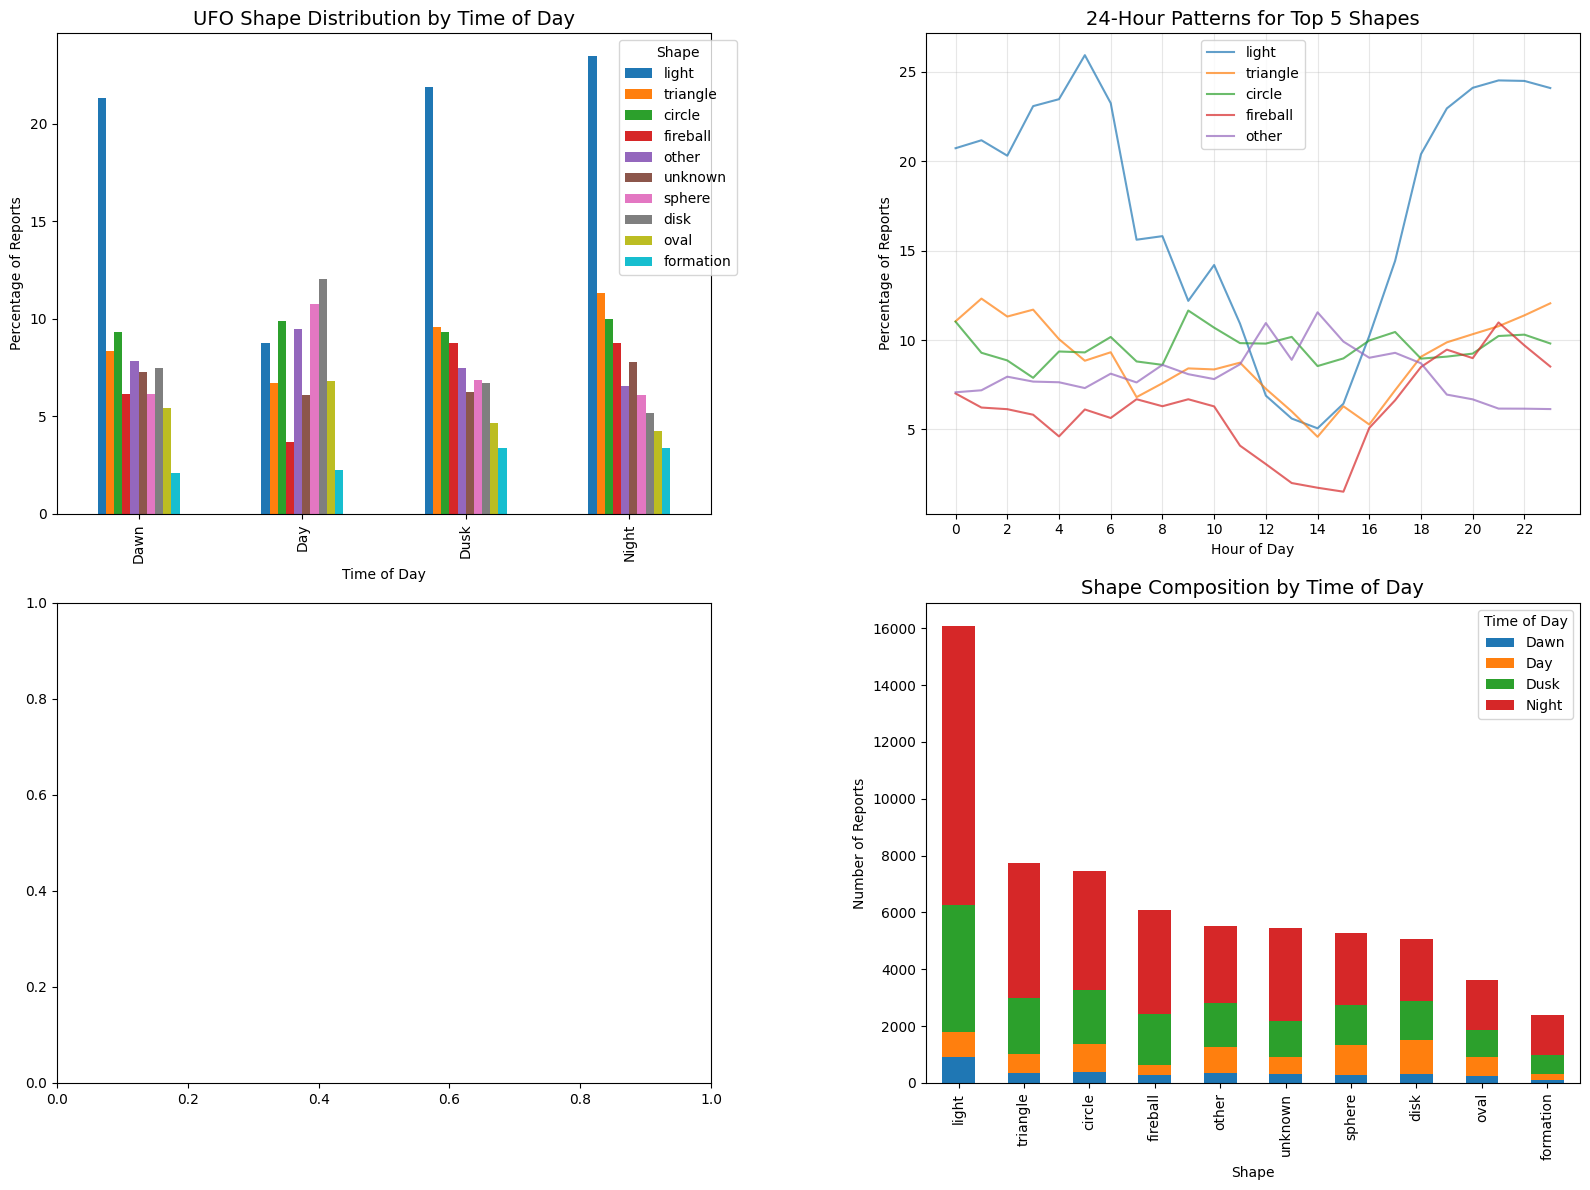


Key Time of Day Insights:
----------------------------------------
Dawn: Most common shape is 'light' (21.3%)
Day: Most common shape is 'disk' (12.0%)
Dusk: Most common shape is 'light' (21.9%)
Night: Most common shape is 'light' (23.5%)


In [ ]:
# Create time of day distributions
tod_shape = joined_temporal.groupby(['time_of_day', 'shape']).size().unstack(fill_value=0)
hour_shape = joined_temporal.groupby(['hour', 'shape']).size().unstack(fill_value=0)

# Normalize
tod_shape_pct = tod_shape.div(tod_shape.sum(axis=1), axis=0) * 100
hour_shape_pct = hour_shape.div(hour_shape.sum(axis=1), axis=0) * 100

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Time of day distribution
tod_order = ['Dawn', 'Day', 'Dusk', 'Night']
tod_shape_pct.reindex(tod_order)[top_shapes].plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title('UFO Shape Distribution by Time of Day', fontsize=14)
axes[0,0].set_xlabel('Time of Day')
axes[0,0].set_ylabel('Percentage of Reports')
axes[0,0].legend(title='Shape', bbox_to_anchor=(1.05, 1))

# Plot 2: 24-hour pattern for top shapes
for shape in top_shapes[:5]:
    axes[0,1].plot(hour_shape_pct.index, hour_shape_pct[shape], label=shape, alpha=0.7)
axes[0,1].set_title('24-Hour Patterns for Top 5 Shapes', fontsize=14)
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Percentage of Reports')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xticks(range(0, 24, 2))


# Plot 4: Stacked area chart for time of day
tod_counts = tod_shape.reindex(tod_order)[top_shapes]
tod_counts.T.plot(kind='bar', stacked=True, ax=axes[1,1])
axes[1,1].set_title('Shape Composition by Time of Day', fontsize=14)
axes[1,1].set_xlabel('Shape')
axes[1,1].set_ylabel('Number of Reports')
axes[1,1].legend(title='Time of Day')

plt.tight_layout()
plt.show()

# Key insights
print("\nKey Time of Day Insights:")
print("-" * 40)
for tod in tod_order:
    if tod in tod_shape_pct.index:
        top_shape = tod_shape_pct.loc[tod].idxmax()
        print(f"{tod}: Most common shape is '{top_shape}' ({tod_shape_pct.loc[tod, top_shape]:.1f}%)")

4 - 最dominate的是night
2 - 下午最少

### 3.4.4 Time-Series of Reporting Patterns

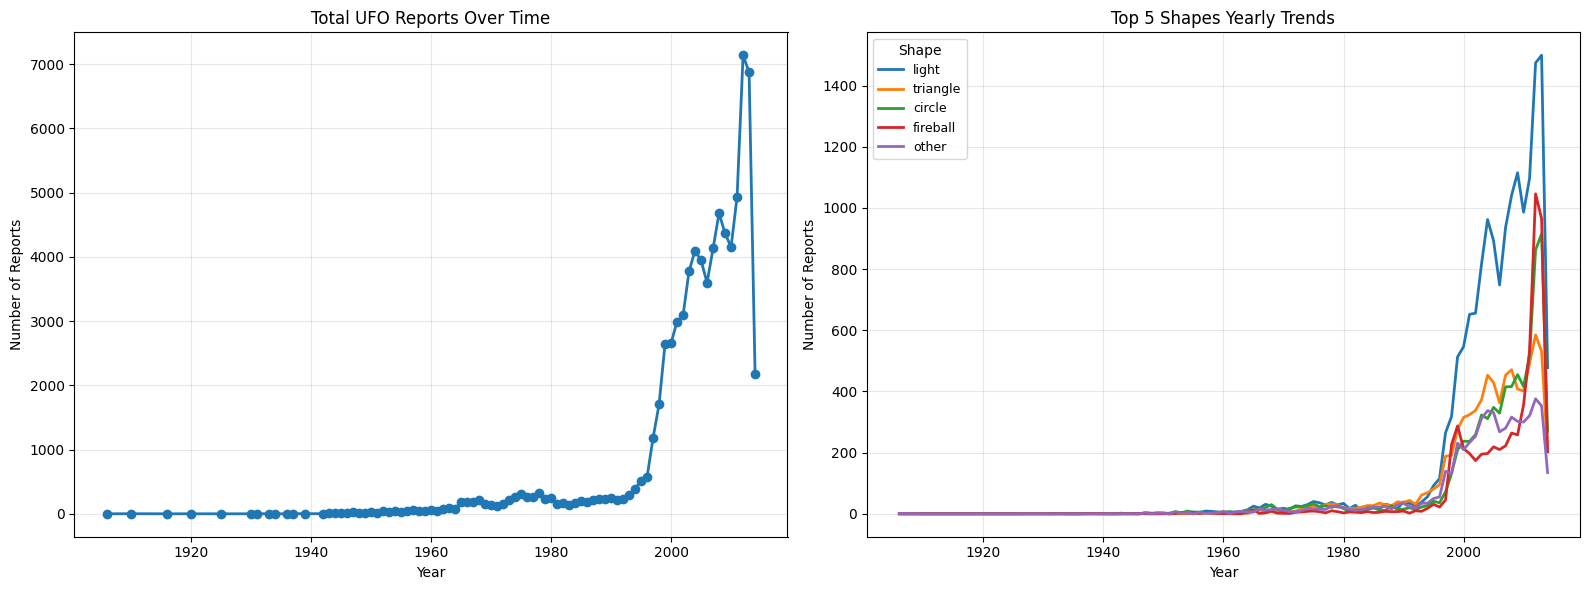


Time Series Summary Statistics:
----------------------------------------
Total reports in dataset: 76,559
Date range: 1906 - 2014
Peak year: 2012 (7,136 reports)
Average yearly reports: 901
Median yearly reports: 173


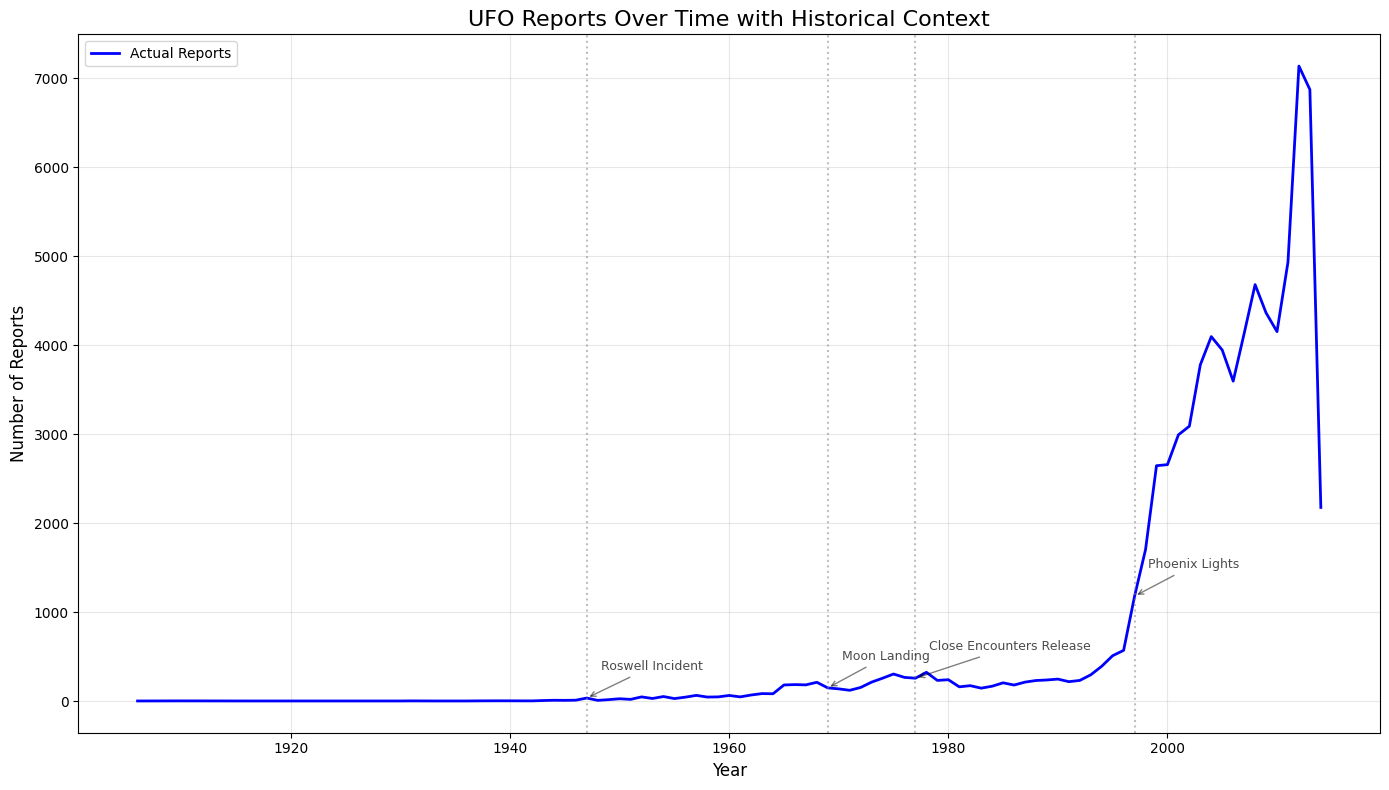

In [ ]:
yearly_total = joined_temporal.groupby("year").size()

# Reports per (year, shape)
yearly_shape = joined_temporal.groupby(["year", "shape"]).size().unstack(fill_value=0)

# Top 5 most frequent shapes overall
shape_totals = yearly_shape.sum(axis=0).sort_values(ascending=False)
top_shapes = shape_totals.index[:5]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Plot 1: Total reports over time
axes[0].plot(
    yearly_total.index,
    yearly_total.values,
    marker="o",
    linestyle="-",
    linewidth=2,
)
axes[0].set_title("Total UFO Reports Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Reports")
axes[0].grid(True, alpha=0.3)

# Plot 2: Top 5 shapes yearly trends
for shape in top_shapes:
    axes[1].plot(
        yearly_shape.index,
        yearly_shape[shape],
        linestyle="-",
        linewidth=2,
        label=shape,
    )

axes[1].set_title("Top 5 Shapes Yearly Trends")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of Reports")
axes[1].legend(title="Shape", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nTime Series Summary Statistics:")
print("-" * 40)
print(f"Total reports in dataset: {len(joined_temporal):,}")
print(f"Date range: {joined_temporal['year'].min()} - {joined_temporal['year'].max()}")
print(f"Peak year: {yearly_total.idxmax()} ({yearly_total.max():,} reports)")
print(f"Average yearly reports: {yearly_total.mean():.0f}")
print(f"Median yearly reports: {yearly_total.median():.0f}")

# Create final summary visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot actual data
ax.plot(yearly_total.index, yearly_total.values, 'b-', label='Actual Reports', linewidth=2)

# Add major events or periods (you can customize these)
major_events = {
    1947: 'Roswell Incident',
    1969: 'Moon Landing',
    1977: 'Close Encounters Release',
    1997: 'Phoenix Lights',
    2017: 'Pentagon UFO Videos'
}

for year, event in major_events.items():
    if year in yearly_total.index:
        ax.axvline(x=year, color='gray', linestyle=':', alpha=0.5)
        ax.annotate(event, xy=(year, yearly_total.loc[year]),
                   xytext=(10, 20), textcoords='offset points',
                   fontsize=9, alpha=0.7,
                   arrowprops=dict(arrowstyle='->', alpha=0.5))

ax.set_title('UFO Reports Over Time with Historical Context', fontsize=16)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Reports', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

peak year - 2012年 - 发生了什么事让他变多了 - 2012世界末日

## 3.5 Duration Analysis

In [ ]:
def prepare_duration_data(df):
    """Clean and prepare duration data for analysis"""
    df = df.copy()

    # Convert to numeric, handling errors
    df['duration_seconds'] = pd.to_numeric(df['duration (seconds)'], errors='coerce')

    # Remove invalid durations
    df = df[df['duration_seconds'].notna()]
    df = df[df['duration_seconds'] > 0]

    # Cap at reasonable maximum (1 week = 604800 seconds)
    df.loc[df['duration_seconds'] > 604800, 'duration_seconds'] = 604800

    # Add useful transformations
    df['duration_minutes'] = df['duration_seconds'] / 60
    df['duration_hours'] = df['duration_seconds'] / 3600
    df['log_duration'] = np.log10(df['duration_seconds'] + 1)

    return df

# Prepare the data
duration_df = prepare_duration_data(joined)

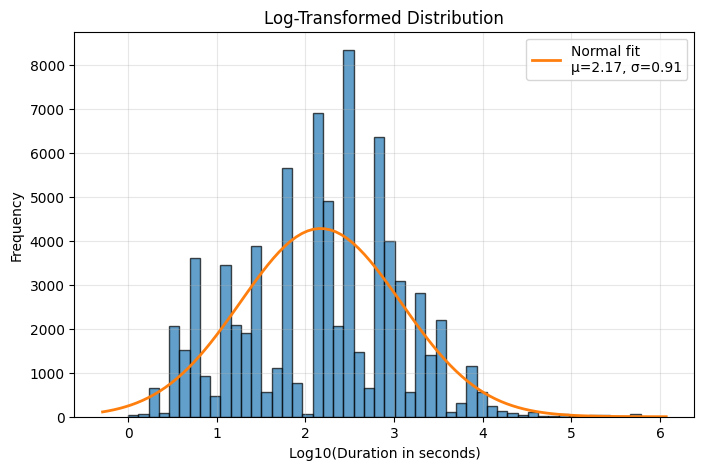

In [ ]:
plt.figure(figsize=(8, 5))

# Histogram
plt.hist(
    duration_df['log_duration'],
    bins=50,
    alpha=0.7,
    edgecolor='black')

plt.xlabel('Log10(Duration in seconds)')
plt.ylabel('Frequency')
plt.title('Log-Transformed Distribution')
plt.grid(True, alpha=0.3)

# Fit normal distribution
mu, std = stats.norm.fit(duration_df['log_duration'])
xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

# Scale PDF to histogram
plt.plot(x,
    p * len(duration_df['log_duration']) * (xmax - xmin) / 50,
    linewidth=2,
    label=f'Normal fit\nμ={mu:.2f}, σ={std:.2f}'
)

plt.legend()
plt.show()


/tmp/ipython-input-918607705.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




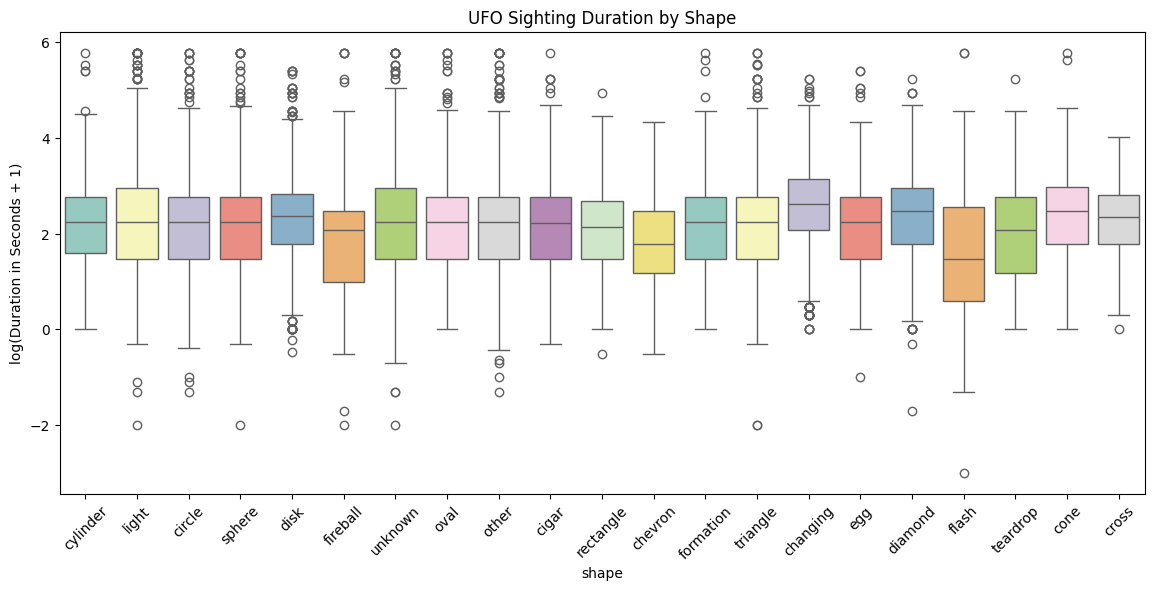

In [ ]:
plt.figure(figsize=(14,6))
sns.boxplot(
    data=duration_df,
    x="shape",
    y=np.log10(duration_df["duration_seconds"]),
    palette="Set3"
)
plt.xticks(rotation=45)
plt.ylabel("log(Duration in Seconds + 1)")
plt.title("UFO Sighting Duration by Shape")
plt.show()


In [ ]:
duration_df.nlargest(10, "duration_seconds")[["datetime","shape","duration_seconds","city","state"]]


,datetime,shape,duration_seconds,city,state
559,1983-10-01 17:00:00,sphere,604800.0,Birmingham,England
693,2001-10-01 00:00:00,other,604800.0,Chulucanas,Piura
3476,2007-10-21 01:00:00,light,604800.0,Maysville,Kentucky
4123,2011-10-23 01:30:00,triangle,604800.0,Alamo,Tennessee
6991,2013-10-07 20:00:00,circle,604800.0,Oklahoma City,Oklahoma
7101,2008-10-08 21:00:00,light,604800.0,Ukiah,California
8837,2013-11-12 21:30:00,sphere,604800.0,Mount Isa,Queensland
12324,2005-11-22 04:00:00,light,604800.0,Hemet,California
14090,2007-01-13 11:30:00,unknown,604800.0,Trujillo Alto,Trujillo Alto
14181,2011-11-03 19:21:00,unknown,604800.0,Woodville,Wisconsin


## 3.6 Education-Level Influence EDA -- TBD

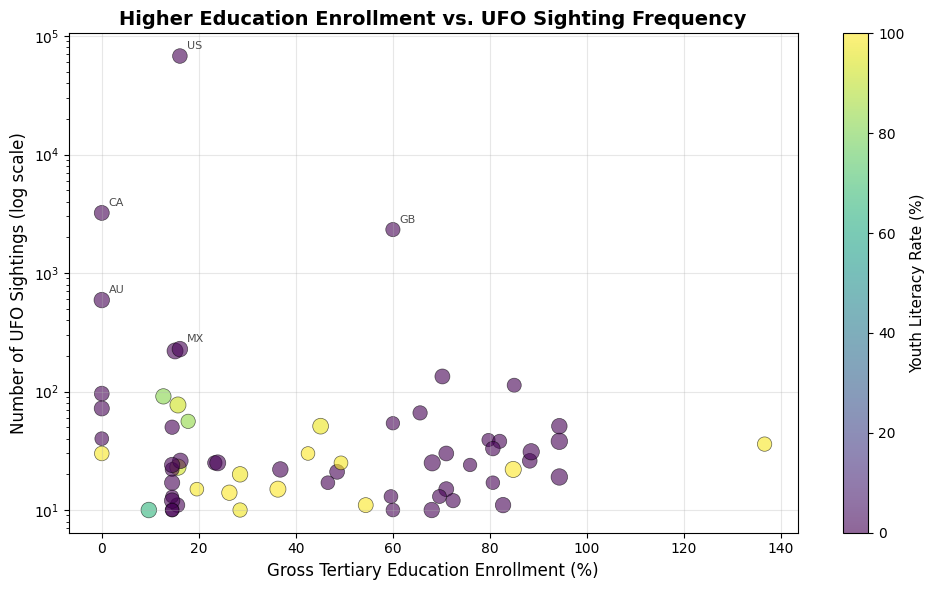

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

country_education = joined.groupby('country').agg({
    'shape': 'count',  # Total sightings
    'Gross_Tertiary_Education_Enrollment': 'first',
    'Youth_15_24_Literacy_Rate_Both': 'first',
    'Unemployment_Rate': 'first',
    'population': 'mean',
    'viirs_annual_ave': 'mean'
}).rename(columns={'shape': 'sighting_count'}).reset_index()

# Remove countries with very few sightings
country_education = country_education[country_education['sighting_count'] >= 10]

# Calculate sightings per capita (using mean city population as proxy)
country_education['sightings_per_capita'] = (
    country_education['sighting_count'] / country_education['population']
)

# Filter rows with valid values
df_edu = country_education.dropna(
    subset=["Gross_Tertiary_Education_Enrollment"]
).copy()

# Compute marker sizes using population
marker_sizes = np.log10(df_edu["population"] + 1) * 20

# Create single plot
plt.figure(figsize=(10, 6))

sc = plt.scatter(
    df_edu["Gross_Tertiary_Education_Enrollment"],
    df_edu["sighting_count"],
    s=marker_sizes,
    c=df_edu["Youth_15_24_Literacy_Rate_Both"],
    cmap="viridis",
    alpha=0.6,
    edgecolors="black",
    linewidth=0.5
)

# Labels + Title
plt.title(
    "Higher Education Enrollment vs. UFO Sighting Frequency",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Gross Tertiary Education Enrollment (%)", fontsize=12)
plt.ylabel("Number of UFO Sightings (log scale)", fontsize=12)
plt.yscale("log")
plt.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(sc)
cbar.set_label("Youth Literacy Rate (%)", fontsize=11)


top_countries = df_edu.nlargest(5, "sighting_count")

for _, row in top_countries.iterrows():
    plt.annotate(
        row["country"].upper(),
        (row["Gross_Tertiary_Education_Enrollment"], row["sighting_count"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        alpha=0.7
    )
plt.tight_layout()
plt.show()


## 3.7 Feature Correlation Matrix (+Feature Engineering?

In [ ]:
numeric_cols = [
    "latitude","longitude","population",
    "avg_annual_temp(°C)","temp_seasonality",
    "annual_precipitation(mm)","elevation(m)",
    "viirs_annual_ave","dist_to_nearest_airport(m)",
    "Gross_Tertiary_Education_Enrollment",
    "Youth_15_24_Literacy_Rate_Both",
    "Unemployment_Rate",
]

corr = joined[numeric_cols].corr()


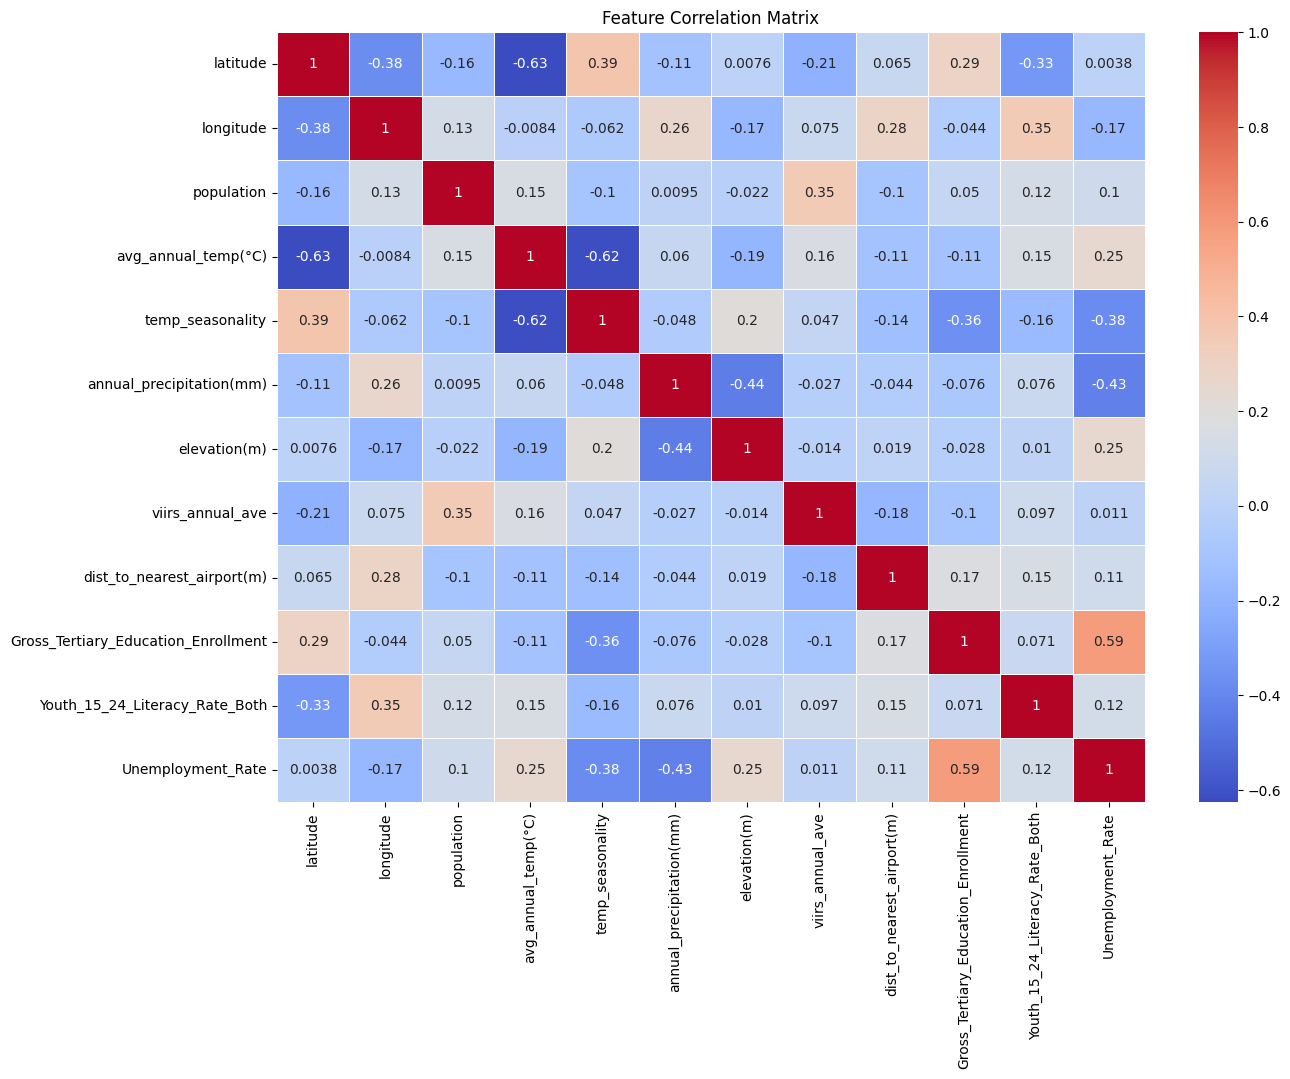

In [ ]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()


## Part 4 Feature Engineering

## Part 5 Baseline Modeling

In this section, we will build 2 baseline models for our UFO sightings shape prediction.

The first baseline model is a simple majority class classifier. This is a very trivial model that always predict the most common type in our shape class. The purpose of setting this baseline model is to provide us with a lower bound of model performance. In our further study, any useful model should have better performance than the naive majority class classifier.

In [ ]:
feature_cols = [
    "latitude",
    "longitude",
    "population",
    "avg_annual_temp(°C)",
    "temp_seasonality",
    "annual_precipitation(mm)",
    "elevation(m)",
    "viirs_annual_ave",
    "dist_to_nearest_airport(m)",
    "Gross_Tertiary_Education_Enrollment",
    "Youth_15_24_Literacy_Rate_Both",
    "Unemployment_Rate",
]
X = joined[feature_cols]
y = joined["shape"]

In [ ]:
model_df = pd.concat([X, y], axis=1).dropna(subset=feature_cols + ["shape"])
model_df

,latitude,longitude,population,avg_annual_temp(°C),temp_seasonality,annual_precipitation(mm),elevation(m),viirs_annual_ave,dist_to_nearest_airport(m),Gross_Tertiary_Education_Enrollment,Youth_15_24_Literacy_Rate_Both,Unemployment_Rate,shape
0,29.883056,-97.941111,74469.0,20.008333,706.189636,879.0,179.0,35.295166,780.873079,16.1,0.0,4.10,cylinder
1,29.384210,-98.581082,2069843.0,20.741667,673.089294,790.0,222.0,45.640274,2.060551,16.1,0.0,4.10,light
2,53.200000,-2.916667,87507.0,9.645833,447.607056,691.0,21.0,0.000000,7217.481990,60.0,0.0,3.85,circle
3,28.978333,-96.645833,66523.0,21.533333,614.785034,958.0,35.0,42.157391,1126.489912,16.1,0.0,4.10,circle
4,21.418056,-157.803611,35945.0,23.845833,138.899246,2606.0,31.0,10.316186,5179.789007,16.1,0.0,4.10,light
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80327,36.165833,-86.784444,1178679.0,15.220833,863.108704,1254.0,132.0,77.557053,1955.936400,14.5,0.0,2.04,light
80328,43.613611,-116.202500,449428.0,10.808333,855.434021,321.0,840.0,18.624582,1168.251147,16.1,0.0,4.10,circle
80329,38.297222,-122.284444,81643.0,15.312500,480.937195,681.0,13.0,14.898866,2122.386753,16.1,0.0,4.10,other
80330,38.901111,-77.265556,16369.0,13.150000,876.047424,1040.0,122.0,15.233685,2715.740698,0.0,0.0,0.00,circle


In [ ]:
model_df.isnull().any()

,0
latitude,False
longitude,False
population,False
avg_annual_temp(°C),False
temp_seasonality,False
annual_precipitation(mm),False
elevation(m),False
viirs_annual_ave,False
dist_to_nearest_airport(m),False
Gross_Tertiary_Education_Enrollment,False


Here's some basic infomation of our target class.

In [ ]:
print("Number of samples after filtering:", len(model_df))
print("Number of classes:", y.nunique())
print("Class distribution:")
print(y.value_counts(normalize=True).round(3))

Number of samples after filtering: 76559
Number of classes: 21
Class distribution:
shape
light        0.210
triangle     0.101
circle       0.097
fireball     0.079
other        0.072
unknown      0.071
sphere       0.069
disk         0.066
oval         0.047
formation    0.031
cigar        0.026
changing     0.025
flash        0.017
rectangle    0.017
cylinder     0.017
diamond      0.015
chevron      0.012
egg          0.010
teardrop     0.010
cone         0.004
cross        0.003
Name: proportion, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345, stratify=y)
print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))


Train size: 61247
Test size: 15312


For a majority-class model, it always predict the most frequent shape in our training dataset (i.e. the majority class). So now we will figure out what this shape is.

In [ ]:
majority_class = y_train.value_counts().idxmax()
print("\nMajority class in training data:", majority_class)


Majority class in training data: light


Now we can make our prediction.

In [ ]:
y_pred_majority = np.full_like(y_test, fill_value=majority_class)
majority_acc = accuracy_score(y_test, y_pred_majority)
print("Majority-class baseline accuracy on test set: {:.4f}".format(majority_acc))

Majority-class baseline accuracy on test set: 0.2102


The second baseline model is the multinormal logistic regression model. It is simple, interpretable, and suitable for our task. This baseline model defines another baseline: this is a very simple model and subsequent models should have better performance than it.

To fit a multinormal logistic regression, we will standardize all the numeric features.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Multinomial Logistic Regression Model
log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000
)

In [ ]:
log_reg.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



LogisticRegression(max_iter=1000, multi_class='multinomial')

In [ ]:
# Predictions
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

# Evaluation
multi_log_train_acc = accuracy_score(y_train, y_train_pred)
multi_log_test_acc = accuracy_score(y_test, y_test_pred)

In [ ]:
print("Logistic Regression (multinomial) performance:")
print("  Train accuracy: {:.4f}".format(multi_log_train_acc))
print("  Test accuracy:  {:.4f}".format(multi_log_test_acc))
print("Majority baseline accuracy: {:.4f}".format(majority_acc))

Logistic Regression (multinomial) performance:
  Train accuracy: 0.2102
  Test accuracy:  0.2102
Majority baseline accuracy: 0.2102


Notice that the train/test accuracy of our multinormal logistic regression model is almost the same as our majority baseline accuray. We can further check the underlying reason.

In [ ]:
pd.Series(y_test_pred).value_counts()

,count
light,15298
other,8
circle,5
triangle,1


Out of all test predictions, almost all test cases are assigned with label light. This extreme imbalance indicates that the multinormal logistic regression model defaults to predicting the dominant class in nearly every situation, which make it highly similar to the majority class classifier.

Such behavior is typical when the features provide little linear separation among classes or when the classifier is strongly influenced by the underlying class imbalance in the training data.

Given that both the majority-class baseline and the logistic regression model converge to nearly identical predictions, it is clear that linear decision boundaries are insufficient for distinguishing UFO shapes from the available features.

For our next steps, we should start considering models capable of expressing richer structure in the data since we have seen that the underlying relationships are likely nonlinear.

Tree-based ensemble methods such as Random Forests may be useful for the next step, and another direction is to explore kernel-based methods like SVM or shallow neural networks, so that we can have model curved decision surfaces that logistic regression cannot capture.